In [1]:
import numpy as np
import matplotlib.pyplot as plt

# linear regression
from sklearn.linear_model import LinearRegression

In [2]:
shear_data = np.load("../../../data/Priyam_dataset/shear_results.pkl", allow_pickle=True)
shear_data.keys()

dict_keys(['Flux', 'input_shear', 'measured_shapes', 'input_shapes'])

In [3]:
print(shear_data['input_shear'].shape)
print(shear_data['input_shapes'].shape)
print(shear_data['measured_shapes'].shape)

(100, 2)
(100, 10000, 2)
(100, 10000, 2)


In [4]:
Ngal = 10000
shear_diff = []
shear_sigma = []
for shear, ell_meas in zip(shear_data['input_shear'], shear_data['measured_shapes'][:,:Ngal,:]):
    shear_estim = np.mean(ell_meas, axis=0)
    sigma = np.std(ell_meas, axis=0)/np.sqrt(Ngal)
    shear_diff.append(shear_estim - shear)
    shear_sigma.append(sigma)
shear_diff = np.array(shear_diff)
shear_sigma = np.array(shear_sigma)

In [5]:
# Sort by increasing input shear for better plotting
sort_idx_1 = np.argsort(shear_data['input_shear'][:,0])
shear_gt_1 = shear_data['input_shear'][sort_idx_1,0]
shear_err_1 = shear_diff[sort_idx_1,0]
shear_sig_1 = shear_sigma[sort_idx_1,0]
sort_idx_2 = np.argsort(shear_data['input_shear'][:,1])
shear_gt_2 = shear_data['input_shear'][sort_idx_2,1]
shear_err_2 = shear_diff[sort_idx_2,1]
shear_sig_2 = shear_sigma[sort_idx_2,1]

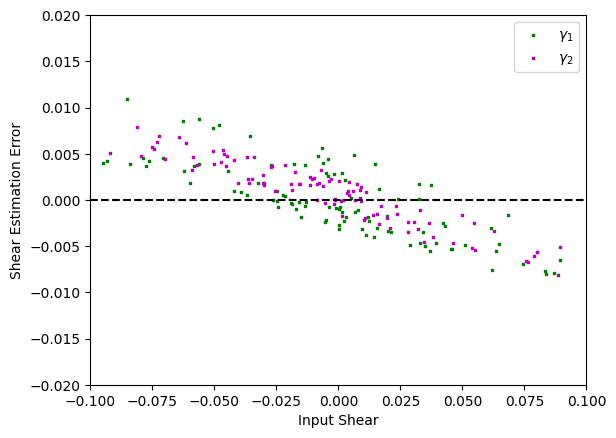

In [6]:
plt.scatter(shear_gt_1, shear_err_1, marker='s', c='g', s=4, label=r"$\gamma_1$")
plt.scatter(shear_gt_2, shear_err_2, marker='s', c='m', s=4, label=r"$\gamma_2$")
plt.axhline(0, color='k', linestyle='--')
plt.xlabel("Input Shear")
plt.ylabel("Shear Estimation Error")
plt.legend()
plt.xlim(-0.1, 0.1)
plt.ylim(-0.02, 0.02)
plt.show()

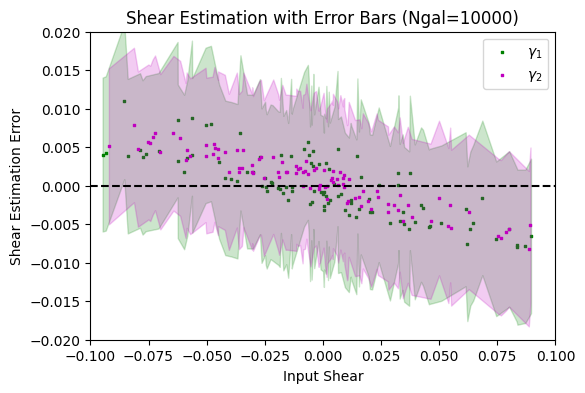

In [7]:
plt.figure(figsize=(6,4))
plt.title("Shear Estimation with Error Bars (Ngal={})".format(Ngal))
plt.fill_between(shear_gt_1, shear_err_1-shear_sig_1*3, shear_err_1+shear_sig_1*3, color='g', alpha=0.2)
plt.scatter(shear_gt_1, shear_err_1, marker='s', c='g', s=4, label=r"$\gamma_1$")
# plt.errorbar(shear_gt_1, shear_err_1, yerr=shear_sig_1*3, fmt='.', c='g', label=r"$\gamma_1$", alpha=0.1)
plt.fill_between(shear_gt_2, shear_err_2-shear_sig_2*3, shear_err_2+shear_sig_2*3, color='m', alpha=0.2)
plt.scatter(shear_gt_2, shear_err_2, marker='s', c='m', s=4, label=r"$\gamma_2$")
# plt.errorbar(shear_gt_2, shear_err_2, yerr=shear_sig_2*3, fmt='.', c='m', label=r"$\gamma_2$", alpha=0.1)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel("Input Shear")
plt.ylabel("Shear Estimation Error")
plt.legend()
plt.xlim(-0.1, 0.1)
plt.ylim(-0.02, 0.02)
plt.show()

# Load our results

In [8]:
g1_gt_ours = np.array([0, 0.05, -0.05, -0.025, 0.025, -0.0125, -0.0375, 0.0125, 0.0375])
g2_gt_ours = np.array([0, -0.05, 0.05, -0.025, 0.025, 0.0125, 0.0375, -0.0375, -0.0125])

combined_results_files = [
    "g_0_0/combined_gmm_results.npz",
    "g_+05_-05/combined_gmm_results.npz",
    "g_-05_+05/combined_gmm_results.npz",
    "g_-025_-025/combined_gmm_results.npz",
    "g_+025_+025/combined_gmm_results.npz",
    "g_-0125_+0125/combined_gmm_results.npz",
    "g_-0375_+0375/combined_gmm_results.npz",
    "g_+0125_-0375/combined_gmm_results.npz",
    "g_+0375_-0125/combined_gmm_results.npz",
]
g1_est_ours = []
g2_est_ours = []
g1_sigma_ours = []
g2_sigma_ours = []


for file in combined_results_files:
    results = np.load(file, allow_pickle=True)
    g1_est_ours.append(results["mean"][0])
    g2_est_ours.append(results["mean"][1])
    g1_sigma_ours.append(np.sqrt(results["cov"][0, 0]))
    g2_sigma_ours.append(np.sqrt(results["cov"][1, 1]))

g1_est_ours = np.array(g1_est_ours)
g2_est_ours = np.array(g2_est_ours)
g1_sigma_ours = np.array(g1_sigma_ours)
g2_sigma_ours = np.array(g2_sigma_ours)
g1_err_ours = g1_est_ours - g1_gt_ours
g2_err_ours = g2_est_ours - g2_gt_ours

# Plot our results vs DeepShape

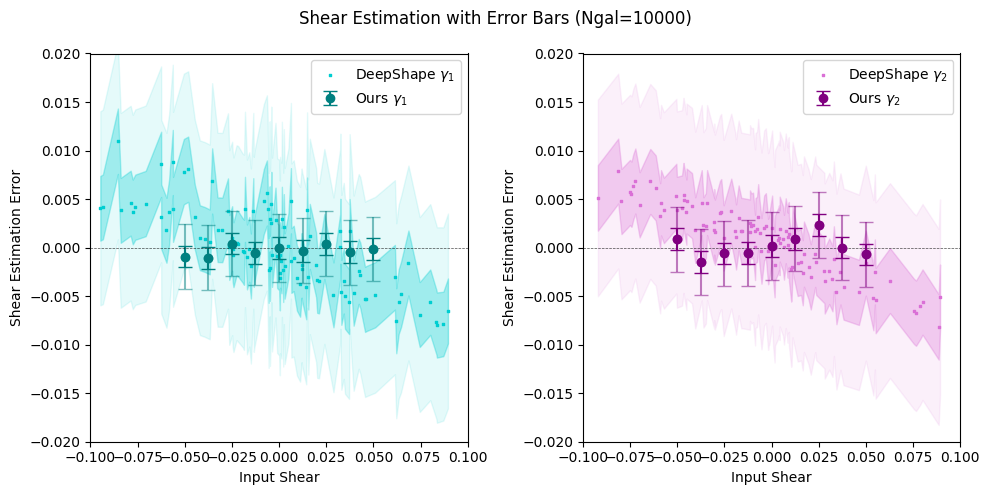

In [9]:
Ngal = 10_000

shear_diff = []
shear_sigma = []
# idx_rand = np.random.choice(shear_data['measured_shapes'].shape[1], Ngal, replace=False)
for shear, ell_meas in zip(shear_data['input_shear'], shear_data['measured_shapes']):
    # Shuffle and get the the first Ngal measurements
    np.random.shuffle(ell_meas)
    ell_meas = ell_meas[:Ngal]
    shear_estim = np.mean(ell_meas, axis=0)
    sigma = np.std(ell_meas, axis=0)/np.sqrt(Ngal)
    shear_diff.append(shear_estim - shear)
    shear_sigma.append(sigma)
shear_diff = np.array(shear_diff)
shear_sigma = np.array(shear_sigma)

# Sort by increasing input shear for better plotting
sort_idx_1 = np.argsort(shear_data['input_shear'][:,0])
shear_gt_1 = shear_data['input_shear'][sort_idx_1,0]
shear_err_1 = shear_diff[sort_idx_1,0]
shear_sig_1 = shear_sigma[sort_idx_1,0]
sort_idx_2 = np.argsort(shear_data['input_shear'][:,1])
shear_gt_2 = shear_data['input_shear'][sort_idx_2,1]
shear_err_2 = shear_diff[sort_idx_2,1]
shear_sig_2 = shear_sigma[sort_idx_2,1]

plt.figure(figsize=(10,5))
plt.suptitle("Shear Estimation with Error Bars (Ngal={})".format(Ngal))

plt.subplot(1,2,1)
plt.fill_between(shear_gt_1, shear_err_1-shear_sig_1*3, shear_err_1+shear_sig_1*3, color='darkturquoise', alpha=0.1)
plt.fill_between(shear_gt_1, shear_err_1-shear_sig_1, shear_err_1+shear_sig_1, color='darkturquoise', alpha=0.3)
plt.scatter(shear_gt_1, shear_err_1, marker='s', c='darkturquoise', s=4, label=r"DeepShape $\gamma_1$")
plt.errorbar(g1_gt_ours, g1_err_ours, yerr=g1_sigma_ours, fmt='o', c='teal', label='Ours $\gamma_1$', capsize=5)
plt.errorbar(g1_gt_ours, g1_err_ours, yerr=g1_sigma_ours*3, fmt='o', c='teal', alpha=0.5, capsize=5)


plt.axhline(0, color='k', linestyle='--', alpha=0.7, linewidth=0.5)
plt.xlabel("Input Shear")
plt.ylabel("Shear Estimation Error")
plt.xlim(-0.1, 0.1)
plt.ylim(-0.02, 0.02)
plt.legend()

plt.subplot(1,2,2)
# plt.errorbar(shear_gt_1, shear_err_1, yerr=shear_sig_1*3, fmt='.', c='g', label=r"$\gamma_1$", alpha=0.1)
plt.fill_between(shear_gt_2, shear_err_2-shear_sig_2*3, shear_err_2+shear_sig_2*3, color='orchid', alpha=0.1)
plt.fill_between(shear_gt_2, shear_err_2-shear_sig_2, shear_err_2+shear_sig_2, color='orchid', alpha=0.3)
plt.scatter(shear_gt_2, shear_err_2, marker='s', c='orchid', s=4, label=r"DeepShape $\gamma_2$")
# plt.errorbar(shear_gt_2, shear_err_2, yerr=shear_sig_2*3, fmt='.', c='m', label=r"$\gamma_2$", alpha=0.1)
plt.axhline(0, color='k', linestyle='--', alpha=0.7, linewidth=0.5)
plt.xlabel("Input Shear")
plt.ylabel("Shear Estimation Error")
plt.xlim(-0.1, 0.1)
plt.ylim(-0.02, 0.02)
plt.errorbar(g2_gt_ours, g2_err_ours, yerr=g2_sigma_ours, fmt='o', c='purple', label='Ours $\gamma_2$', capsize=5)
plt.errorbar(g2_gt_ours, g2_err_ours, yerr=g2_sigma_ours*3, fmt='o', c='purple', alpha=0.5, capsize=5)
plt.legend()

plt.tight_layout()
plt.show()

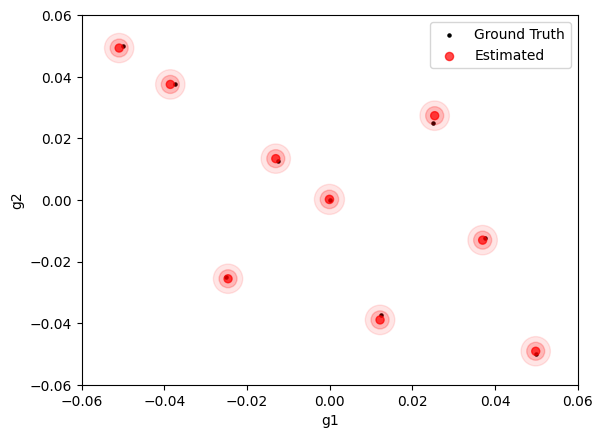

In [10]:
g2_gt_ours
g2_est_ours

plt.scatter(g1_gt_ours, g2_gt_ours, marker='o', c='k', s=5, label='Ground Truth')
plt.scatter(g1_est_ours, g2_est_ours, marker='o', c='r', s=g2_sigma_ours*.3e5, label='Estimated', alpha=0.7)
plt.scatter(g1_est_ours, g2_est_ours, marker='o', c='r', s=g2_sigma_ours*1.5e5, alpha=0.2)
plt.scatter(g1_est_ours, g2_est_ours, marker='o', c='r', s=g2_sigma_ours*4e5, alpha=0.1)

plt.xlabel("g1")
plt.ylabel("g2")
plt.legend()
plt.xlim(-0.06, 0.06)
plt.ylim(-0.06, 0.06)
plt.show()

In [11]:
lr_1 = LinearRegression()
lr_1.fit(shear_gt_1.reshape(-1,1), shear_err_1.reshape(-1,1))
# print(lr_1.coef_, lr_1.intercept_)
fit_vals_1 = lr_1.predict(shear_gt_1.reshape(-1,1))[:,0]

lr_2 = LinearRegression()
lr_2.fit(shear_gt_2.reshape(-1,1), shear_err_2.reshape(-1,1))
# print(lr_2.coef_, lr_2.intercept_)
fit_vals_2 = lr_1.predict(shear_gt_2.reshape(-1,1))[:,0]


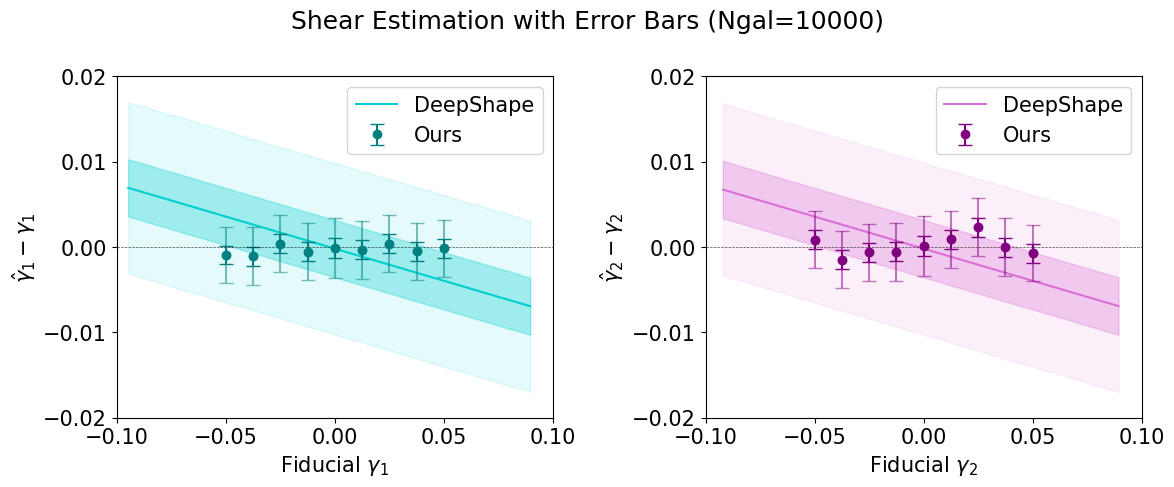

In [12]:
Ngal = 10_000

shear_diff = []
shear_sigma = []
# idx_rand = np.random.choice(shear_data['measured_shapes'].shape[1], Ngal, replace=False)
for shear, ell_meas in zip(shear_data['input_shear'], shear_data['measured_shapes']):
    # Shuffle and get the the first Ngal measurements
    np.random.shuffle(ell_meas)
    ell_meas = ell_meas[:Ngal]
    shear_estim = np.mean(ell_meas, axis=0)
    sigma = np.std(ell_meas, axis=0)/np.sqrt(Ngal)
    shear_diff.append(shear_estim - shear)
    shear_sigma.append(sigma)
shear_diff = np.array(shear_diff)
shear_sigma = np.array(shear_sigma)

# Sort by increasing input shear for better plotting
sort_idx_1 = np.argsort(shear_data['input_shear'][:,0])
shear_gt_1 = shear_data['input_shear'][sort_idx_1,0]
shear_err_1 = shear_diff[sort_idx_1,0]
shear_sig_1 = shear_sigma[sort_idx_1,0]
sort_idx_2 = np.argsort(shear_data['input_shear'][:,1])
shear_gt_2 = shear_data['input_shear'][sort_idx_2,1]
shear_err_2 = shear_diff[sort_idx_2,1]
shear_sig_2 = shear_sigma[sort_idx_2,1]

# Set matplotlib fontsize
plt.rcParams.update({'font.size': 15})

plt.figure(figsize=(12,5))
plt.suptitle("Shear Estimation with Error Bars (Ngal={})".format(Ngal))

plt.subplot(1,2,1)
# plt.fill_between(shear_gt_1, shear_err_1-shear_sig_1*3, shear_err_1+shear_sig_1*3, color='darkturquoise', alpha=0.1)
# plt.fill_between(shear_gt_1, shear_err_1-shear_sig_1, shear_err_1+shear_sig_1, color='darkturquoise', alpha=0.3)
# plt.scatter(shear_gt_1, shear_err_1, marker='s', c='darkturquoise', s=4, label=r"DeepShape $\gamma_1$")
plt.plot(shear_gt_1, fit_vals_1, color='darkturquoise', label=r"DeepShape")
plt.fill_between(shear_gt_1, fit_vals_1-shear_sig_1*3, fit_vals_1+shear_sig_1*3, color='darkturquoise', alpha=0.1)
plt.fill_between(shear_gt_1, fit_vals_1-shear_sig_1, fit_vals_1+shear_sig_1, color='darkturquoise', alpha=0.3)


plt.errorbar(g1_gt_ours, g1_err_ours, yerr=g1_sigma_ours, fmt='o', c='teal', label='Ours', capsize=5)
plt.errorbar(g1_gt_ours, g1_err_ours, yerr=g1_sigma_ours*3, fmt='o', c='teal', alpha=0.5, capsize=5)


plt.axhline(0, color='k', linestyle='--', alpha=0.7, linewidth=0.5)
plt.xlabel(r"Fiducial $\gamma_1$")
plt.ylabel(r"$\hat{\gamma}_1 - \gamma_1$")
plt.xlim(-0.1, 0.1)
plt.ylim(-0.02, 0.02)
plt.yticks(np.arange(-0.02, 0.025, 0.01))
plt.legend()

plt.subplot(1,2,2)
# plt.fill_between(shear_gt_2, shear_err_2-shear_sig_2*3, shear_err_2+shear_sig_2*3, color='orchid', alpha=0.1)
# plt.fill_between(shear_gt_2, shear_err_2-shear_sig_2, shear_err_2+shear_sig_2, color='orchid', alpha=0.3)
# plt.scatter(shear_gt_2, shear_err_2, marker='s', c='orchid', s=4, label=r"DeepShape $\gamma_2$")
plt.plot(shear_gt_2, fit_vals_2, color='orchid', label=r"DeepShape")
plt.fill_between(shear_gt_2, fit_vals_2-shear_sig_2*3, fit_vals_2+shear_sig_2*3, color='orchid', alpha=0.1)
plt.fill_between(shear_gt_2, fit_vals_2-shear_sig_2, fit_vals_2+shear_sig_2, color='orchid', alpha=0.3)

plt.axhline(0, color='k', linestyle='--', alpha=0.7, linewidth=0.5)
plt.xlabel(r"Fiducial $\gamma_2$")
plt.ylabel(r"$\hat{\gamma}_2 - \gamma_2$")
plt.xlim(-0.1, 0.1)
plt.ylim(-0.02, 0.02)
plt.yticks(np.arange(-0.02, 0.025, 0.01))
plt.errorbar(g2_gt_ours, g2_err_ours, yerr=g2_sigma_ours, fmt='o', c='purple', label='Ours', capsize=5)
plt.errorbar(g2_gt_ours, g2_err_ours, yerr=g2_sigma_ours*3, fmt='o', c='purple', alpha=0.5, capsize=5)
plt.legend()

plt.tight_layout()
plt.savefig("results_vs_deepshape.pdf")
plt.show()

In [13]:
lr_ours_1 = LinearRegression()
sorted_g1_gt_ours, sorted_g1_err_ours = zip(*sorted(zip(g1_gt_ours, g1_err_ours)))
sorted_g1_gt_ours = np.array(sorted_g1_gt_ours)
sorted_g1_err_ours = np.array(sorted_g1_err_ours)
lr_ours_1.fit(sorted_g1_gt_ours.reshape(-1,1), sorted_g1_err_ours.reshape(-1,1))
fit_vals_ours_1 = lr_ours_1.predict(sorted_g1_gt_ours.reshape(-1,1))[:,0]
# sigma_fit_ours_1 = np.std(sorted_g1_err_ours - fit_vals_ours_1)

lr_ours_2 = LinearRegression()
sorted_g2_gt_ours, sorted_g2_err_ours = zip(*sorted(zip(g2_gt_ours, g2_err_ours)))
sorted_g2_gt_ours = np.array(sorted_g2_gt_ours)
sorted_g2_err_ours = np.array(sorted_g2_err_ours)
lr_ours_2.fit(sorted_g2_gt_ours.reshape(-1,1), sorted_g2_err_ours.reshape(-1,1))
fit_vals_ours_2 = lr_ours_2.predict(sorted_g2_gt_ours.reshape(-1,1))[:,0]
# sigma_fit_ours_2 = np.std(sorted_g2_err_ours - fit_vals_ours_2)

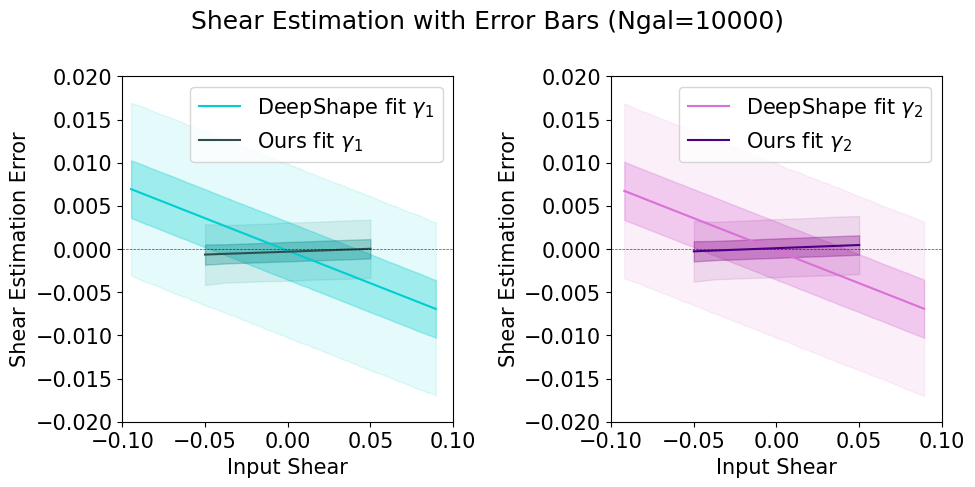

In [14]:
Ngal = 10_000

shear_diff = []
shear_sigma = []
# idx_rand = np.random.choice(shear_data['measured_shapes'].shape[1], Ngal, replace=False)
for shear, ell_meas in zip(shear_data['input_shear'], shear_data['measured_shapes']):
    # Shuffle and get the the first Ngal measurements
    np.random.shuffle(ell_meas)
    ell_meas = ell_meas[:Ngal]
    shear_estim = np.mean(ell_meas, axis=0)
    sigma = np.std(ell_meas, axis=0)/np.sqrt(Ngal)
    shear_diff.append(shear_estim - shear)
    shear_sigma.append(sigma)
shear_diff = np.array(shear_diff)
shear_sigma = np.array(shear_sigma)

# Sort by increasing input shear for better plotting
sort_idx_1 = np.argsort(shear_data['input_shear'][:,0])
shear_gt_1 = shear_data['input_shear'][sort_idx_1,0]
shear_err_1 = shear_diff[sort_idx_1,0]
shear_sig_1 = shear_sigma[sort_idx_1,0]
sort_idx_2 = np.argsort(shear_data['input_shear'][:,1])
shear_gt_2 = shear_data['input_shear'][sort_idx_2,1]
shear_err_2 = shear_diff[sort_idx_2,1]
shear_sig_2 = shear_sigma[sort_idx_2,1]

plt.figure(figsize=(10,5))
plt.suptitle("Shear Estimation with Error Bars (Ngal={})".format(Ngal))

plt.subplot(1,2,1)
# plt.fill_between(shear_gt_1, shear_err_1-shear_sig_1*3, shear_err_1+shear_sig_1*3, color='darkturquoise', alpha=0.1)
# plt.fill_between(shear_gt_1, shear_err_1-shear_sig_1, shear_err_1+shear_sig_1, color='darkturquoise', alpha=0.3)
# plt.scatter(shear_gt_1, shear_err_1, marker='s', c='darkturquoise', s=4, label=r"DeepShape $\gamma_1$")
plt.plot(shear_gt_1, fit_vals_1, color='darkturquoise', label=r"DeepShape fit $\gamma_1$")
plt.fill_between(shear_gt_1, fit_vals_1-shear_sig_1*3, fit_vals_1+shear_sig_1*3, color='darkturquoise', alpha=0.1)
plt.fill_between(shear_gt_1, fit_vals_1-shear_sig_1, fit_vals_1+shear_sig_1, color='darkturquoise', alpha=0.3)


# plt.errorbar(g1_gt_ours, g1_err_ours, yerr=g1_sigma_ours, fmt='o', c='teal', label='Ours $\gamma_1$', capsize=5)
# plt.errorbar(g1_gt_ours, g1_err_ours, yerr=g1_sigma_ours*3, fmt='o', c='teal', alpha=0.5, capsize=5)
plt.plot(sorted_g1_gt_ours, fit_vals_ours_1, color='darkslategrey', label='Ours fit $\gamma_1$')
plt.fill_between(sorted_g1_gt_ours, fit_vals_ours_1-g1_sigma_ours*3, fit_vals_ours_1+g1_sigma_ours*3, color='teal', alpha=0.1)
plt.fill_between(sorted_g1_gt_ours, fit_vals_ours_1-g1_sigma_ours, fit_vals_ours_1+g1_sigma_ours, color='teal', alpha=0.3)


plt.axhline(0, color='k', linestyle='--', alpha=0.7, linewidth=0.5)
plt.xlabel("Input Shear")
plt.ylabel("Shear Estimation Error")
plt.xlim(-0.1, 0.1)
plt.ylim(-0.02, 0.02)
plt.legend()

plt.subplot(1,2,2)
# plt.fill_between(shear_gt_2, shear_err_2-shear_sig_2*3, shear_err_2+shear_sig_2*3, color='orchid', alpha=0.1)
# plt.fill_between(shear_gt_2, shear_err_2-shear_sig_2, shear_err_2+shear_sig_2, color='orchid', alpha=0.3)
# plt.scatter(shear_gt_2, shear_err_2, marker='s', c='orchid', s=4, label=r"DeepShape $\gamma_2$")
plt.plot(shear_gt_2, fit_vals_2, color='orchid', label=r"DeepShape fit $\gamma_2$")
plt.fill_between(shear_gt_2, fit_vals_2-shear_sig_2*3, fit_vals_2+shear_sig_2*3, color='orchid', alpha=0.1)
plt.fill_between(shear_gt_2, fit_vals_2-shear_sig_2, fit_vals_2+shear_sig_2, color='orchid', alpha=0.3)

plt.axhline(0, color='k', linestyle='--', alpha=0.7, linewidth=0.5)
plt.xlabel("Input Shear")
plt.ylabel("Shear Estimation Error")
plt.xlim(-0.1, 0.1)
plt.ylim(-0.02, 0.02)
# plt.errorbar(g2_gt_ours, g2_err_ours, yerr=g2_sigma_ours, fmt='o', c='purple', label='Ours $\gamma_2$', capsize=5)
# plt.errorbar(g2_gt_ours, g2_err_ours, yerr=g2_sigma_ours*3, fmt='o', c='purple', alpha=0.5, capsize=5)
plt.plot(sorted_g2_gt_ours, fit_vals_ours_2, color='indigo', label='Ours fit $\gamma_2$')
plt.fill_between(sorted_g2_gt_ours, fit_vals_ours_2-g2_sigma_ours*3, fit_vals_ours_2+g2_sigma_ours*3, color='purple', alpha=0.1)
plt.fill_between(sorted_g2_gt_ours, fit_vals_ours_2-g2_sigma_ours, fit_vals_ours_2+g2_sigma_ours, color='purple', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()